# 05 — Análise Comparativa Final (UWaveGestureLibrary)

Carrega todos os `metrics.json` da run mais recente e compara raw / db4 /
learned_wavelet entre os backbones.

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
sys.path.insert(0, 'config')
from experiment_config import (
    UWAVE_CONFIG, DATA_DIR, RESULTS_DIR, SEED,
    WAVELET_CONFIG, LEARNED_WAVELET_CONFIG, DL_TRAINING_CONFIG,
    ML_MODELS_CONFIG, ML_SEARCH_CONFIG, build_param_dist,
)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
np.random.seed(SEED)
print('Dataset:', UWAVE_CONFIG['dataset_name'], '| classes:', UWAVE_CONFIG['n_classes'],
      '| seq_len:', UWAVE_CONFIG['sequence_length'], '| canais:', UWAVE_CONFIG['n_features'])

Dataset: UWaveGestureLibrary | classes: 8 | seq_len: 315 | canais: 3


## 1. Carregar resultados da run mais recente

In [2]:
import json
runs = sorted([p for p in RESULTS_DIR.glob('????-??-??*') if (p/'queue_status.json').exists()], reverse=True)
assert runs, 'Nenhuma run encontrada — rode run_dl_queue.py primeiro.'
run_dir = runs[0]; print('Run:', run_dir.name)
rows = [json.loads(f.read_text()) for f in run_dir.rglob('metrics.json')]
df = pd.json_normalize(rows)
for col in ['test_accuracy','test_f1_macro','test_auc_ovr','val_accuracy']:
    df[col] = pd.to_numeric(df.get(col), errors='coerce')
print(len(df), 'configs avaliados')

Run: 2026-05-29_231129
1764 configs avaliados


## 2. Melhor por Model × Mode

In [3]:
best = df.groupby(['model_name','mode'])[['test_accuracy','test_f1_macro','test_auc_ovr']].max()
best.sort_values('test_f1_macro', ascending=False).round(4)

test_accuracy  test_f1_macro  \
model_name  mode                                                      
Transformer learned_wavelet_no_warmup         0.8688         0.8688   
MLP         learned_wavelet                   0.8688         0.8672   
Transformer learned_wavelet                   0.8656         0.8636   
MLP         learned_wavelet_no_warmup         0.8562         0.8559   
            raw                               0.8562         0.8545   
            db4                               0.8562         0.8537   
CNN         learned_wavelet                   0.8531         0.8525   
LSTM        learned_wavelet                   0.8500         0.8473   
            learned_wavelet_no_warmup         0.8500         0.8464   
CNN_LSTM    learned_wavelet_no_warmup         0.8375         0.8380   
LSTM        raw                               0.8344         0.8334   
CNN_LSTM    learned_wavelet                   0.8344         0.8300   
Transformer raw                               0.8312         0.8269   
CNN         learned_wavelet_no_warmup         0.8125         0.8152   
Transformer db4                               0.7938         0.7926   
LSTM        db4                               0.7250         0.7109   
CNN_LSTM    raw                               0.6312         0.6270   
CNN         db4                               0.6125         0.5478   
            raw                               0.3562         0.3033   
CNN_LSTM    db4                               0.2000         0.1541   

                                       test_auc_ovr  
model_name  mode                                     
Transformer learned_wavelet_no_warmup        0.9788  
MLP         learned_wavelet                  0.9836  
Transformer learned_wavelet                  0.9785  
MLP         learned_wavelet_no_warmup        0.9823  
            raw                              0.9759  
            db4                              0.9788  
CNN         learned_wavelet                  0.9801  
LSTM        learned_wavelet                  0.9763  
            learned_wavelet_no_warmup        0.9787  
CNN_LSTM    learned_wavelet_no_warmup        0.9766  
LSTM        raw                              0.9690  
CNN_LSTM    learned_wavelet                  0.9673  
Transformer raw                              0.9679  
CNN         learned_wavelet_no_warmup        0.9782  
Transformer db4                              0.9612  
LSTM        db4                              0.9344  
CNN_LSTM    raw                              0.9231  
CNN         db4                              0.9685  
            raw                              0.8898  
CNN_LSTM    db4                              0.7620

## 3. Heatmap f1_macro (Model × Mode)

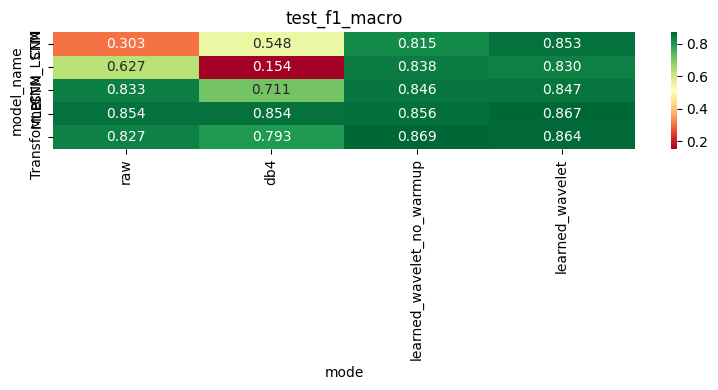

In [4]:
import seaborn as sns
pivot = df.groupby(['model_name','mode'])['test_f1_macro'].max().unstack()
order_m = ['raw','db4','learned_wavelet_no_warmup','learned_wavelet']
pivot = pivot.reindex(columns=[c for c in order_m if c in pivot.columns])
plt.figure(figsize=(8,4)); sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn')
plt.title('test_f1_macro'); plt.tight_layout(); plt.show()

## 4. Raw vs Fixed Wavelet vs Learned Wavelet

In [5]:
def bucket(m):
    if m == 'raw': return 'raw'
    if m == 'db4': return 'fixed_wavelet'
    return 'learned_wavelet'
df['bucket'] = df['mode'].map(bucket)
df.groupby('bucket')[['test_accuracy','test_f1_macro','test_auc_ovr']].agg(['mean','max']).round(4)

test_accuracy         test_f1_macro         test_auc_ovr  \
                         mean     max          mean     max         mean   
bucket                                                                     
fixed_wavelet          0.4239  0.8562        0.3637  0.8537       0.8179   
learned_wavelet        0.7240  0.8688        0.7121  0.8688       0.9431   
raw                    0.5900  0.8562        0.5595  0.8545       0.9004   

                         
                    max  
bucket                   
fixed_wavelet    0.9788  
learned_wavelet  0.9836  
raw              0.9759

## 5. Ranking global (top 15)

In [6]:
cols = ['model_name','mode','config_idx','test_accuracy','test_f1_macro','test_auc_ovr']
df[cols].sort_values('test_f1_macro', ascending=False).head(15).round(4)

,model_name,mode,config_idx,test_accuracy,test_f1_macro,test_auc_ovr
1361,Transformer,learned_wavelet_no_warmup,109,0.8688,0.8688,0.9720
964,MLP,learned_wavelet,38,0.8688,0.8672,0.9739
1385,Transformer,learned_wavelet_no_warmup,110,0.8688,0.8665,0.9684
946,MLP,learned_wavelet,51,0.8625,0.8636,0.9823
370,Transformer,learned_wavelet,70,0.8656,0.8636,0.9748
938,MLP,learned_wavelet,2,0.8625,0.8617,0.9807
416,Transformer,learned_wavelet,124,0.8594,0.8596,0.9666
957,MLP,learned_wavelet,12,0.8562,0.8560,0.9695
176,MLP,learned_wavelet_no_warmup,2,0.8562,0.8559,0.9800
160,MLP,raw,14,0.8562,0.8545,0.9724
